<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
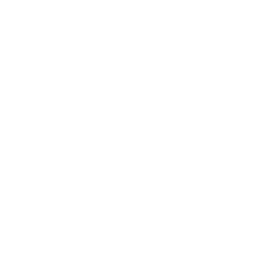
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Σχεδιασμός Λατινικού Τετραγώνου για την Αξιολόγηση Ποικιλιών Καλλιέργειας</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Γεωργία / Σχεδιασμός Πειράματος Αγρού &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Ένα πείραμα αγρού με σχεδιασμό λατινικού τετραγώνου 5x5 συγκρίνει πέντε ποικιλίες σιταριού (ATLAS, BEACON, CREST, DELTA, ENVOY) ελέγχοντας ταυτόχρονα δύο χωρικές κλίσεις παρενόχλησης: τη θέση σειράς και τη θέση στήλης. Μέσα στο πείραμα των 100 τεμαχίων (το πλήρες τετράγωνο επαναλαμβανόμενο τέσσερις φορές), η PROC GLM κατανέμει τη διακύμανση της απόδοσης σε επιδράσεις ποικιλίας, σειράς και στήλης χρησιμοποιώντας αθροίσματα τετραγώνων Τύπου III.

Το προσαρμοσμένο μοντέλο εξηγεί το 26.7% της διακύμανσης της απόδοσης (R-τετράγωνο 0.267, ρίζα MSE 3.65 bu/ac). Η θέση σειράς είναι η κυρίαρχη επίδραση συνομαδοποίησης (F = 4.73, p = 0.0017), επιβεβαιώνοντας μια πραγματική κλίση γονιμότητας βορρά-νότου, ενώ η θέση στήλης συνεισφέρει ελάχιστα (F = 0.77, p = 0.5473). Η επίδραση ποικιλίας είναι οριακή (F = 2.42, p = 0.0545) — ενδεικτική αλλά κάτω από το όριο 0.05 μόλις αφαιρεθούν και οι δύο κατευθύνσεις συνομαδοποίησης. Τα LSMEANS κατατάσσουν την ATLAS ψηλότερα (63.04 bu/ac) και την CREST χαμηλότερα (59.69 bu/ac)· τα μόνα κατά ζεύγη κενά που φτάνουν p < 0.05 είναι ATLAS έναντι CREST, ENVOY και BEACON. Τα διαγνωστικά καταλοίπων (Shapiro-Wilk p = 0.54) υποστηρίζουν την υπόθεση κανονικότητας πίσω από τους ελέγχους F.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------:|
| WORK.FIELD_TRIAL | Συνθετική απόδοση από λατινικό τετράγωνο 5x5 (5 ποικιλίες ισορροπημένες σε 5 θέσεις σειράς και 5 θέσεις στήλης), το τετράγωνο επαναλαμβανόμενο τέσσερις φορές | 100 |

Κάθε ποικιλία εμφανίζεται ακριβώς μία φορά ανά θέση σειράς και μία φορά ανά θέση στήλης μέσα σε κάθε επανάληψη, οπότε τα 100 τεμάχια περιέχουν έναν τέλεια ισορροπημένο σχεδιασμό: 20 τεμάχια ανά ποικιλία, 20 ανά μπλοκ σειράς, 20 ανά μπλοκ στήλης (4 τεμάχια σε κάθε κελί ποικιλίας-ανά-σειρά και σειράς-ανά-στήλη).

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών δεδομένων πειράματος αγρού λατινικού τετραγώνου
   5 ποικιλίες x 5 σειρές x 5 στήλες x 4 επαναλήψεις = 500
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.field_trial;
    CALL streaminit(42);
    /* Πίνακας ανάθεσης λατινικού τετραγώνου (5x5) */
    ARRAY lsq[5, 5] _temporary_ (
        1 2 3 4 5,
        2 3 4 5 1,
        3 4 5 1 2,
        4 5 1 2 3,
        5 1 2 3 4
    );
    ARRAY variety_names[5] $12 _temporary_ ('ATLAS' 'BEACON' 'CREST' 'DELTA' 'ENVOY');
    ARRAY variety_effects[5] _temporary_ (2.5 0 -1.2 1.8 -0.5);
    trial_id = 0;
    ΕΠΑΝΑΛΗΨΗ replicate = 1 ΕΩΣ 20;
        rep_effect = rand('normal', 0, 1.5);
        ΕΠΑΝΑΛΗΨΗ row_pos = 1 ΕΩΣ 5;
            row_effect = (row_pos - 3) * 0.8 + rand('normal', 0, 0.3);
            ΕΠΑΝΑΛΗΨΗ col_pos = 1 ΕΩΣ 5;
                trial_id + 1;
                col_effect = (col_pos - 3) * 0.5 + rand('normal', 0, 0.3);
                variety_idx = lsq[row_pos, col_pos];
                variety = variety_names[variety_idx];
                row_block = cat('R', PUT(row_pos, 1.));
                col_block = cat('C', PUT(col_pos, 1.));
                /* Απόδοση σε bushels ανά στρέμμα (bu/ac) */
                yield_bpa = round(
                    62 + variety_effects[variety_idx]
                    + row_effect + col_effect + rep_effect
                    + rand('normal', 0, 3.5), 0.1);
                ΕΑΝ yield_bpa < 30 ΤΟΤΕ yield_bpa = 30;
                soil_moisture = round(rand('normal', 22, 3), 0.1);
                ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ variety_idx variety_effects1-variety_effects5 rep_effect
         row_effect col_effect;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.field_trial

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.field_trial (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---

                                                  The MEANS Procedure

                                  Analysis Variable : yield_bpa Απόδοση (bu/ac)

        Ποικιλία                  N Obs           Mean        Std Dev
        -------------------------------------------------------------
        ATLAS                        20     63.0350000      4.3026644
        BEACON                       20     60.7200000      3.8883903
        CREST                        20     59.6900000      3.3370173
        DELTA                        20     61.7600000      3.7383362
        ENVOY                        20     60.7100000      4.1825326
        -------------------------------------------------------------

                            Analysis Variable : soil_moisture Υγρασία εδάφους

        Ποικιλία                  N Obs           Mean        Std Dev
        -------------------------------------------------------------
        ATLAS                        20     22.8500000      2.177516


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_variety_row_block.spec.json
NOTE: ODS plot written: freq_mosaic_row_block_col_block.spec.json
NOTE: PROC FREQ statement used.


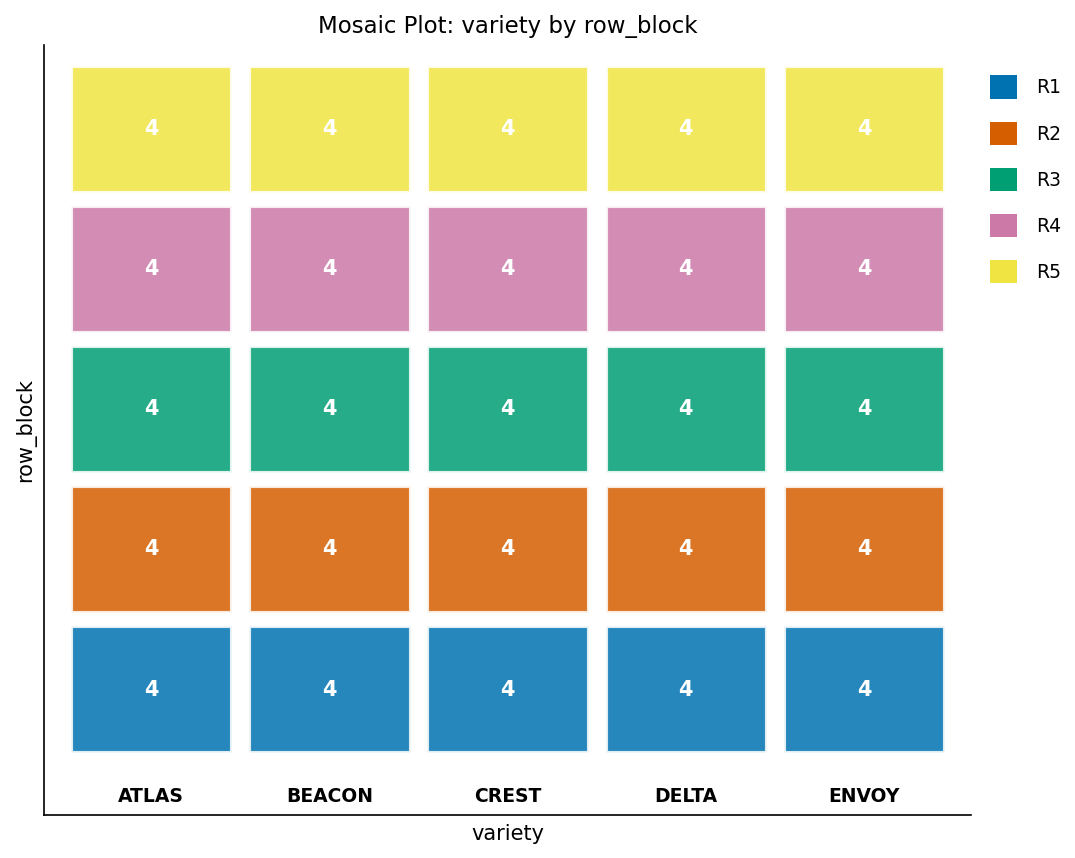

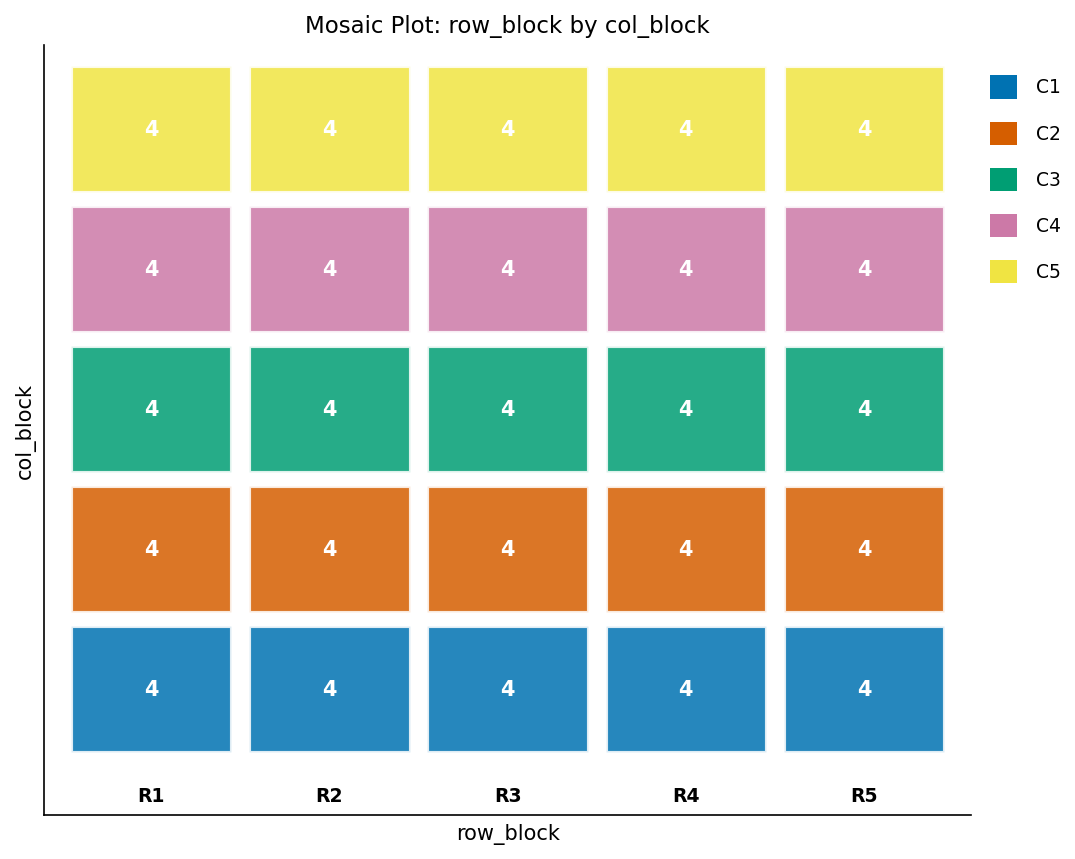

In [2]:
/* --------------------------------------------------------
   Βασική γραμμή: σύνοψη απόδοσης ανά ποικιλία και παράγοντες συνομαδοποίησης
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.field_trial n mean std;
    ΚΛΑΣΗ variety;
    ΜΕΤΑΒΛΗΤΗ yield_bpa soil_moisture;
    ΕΤΙΚΕΤΑ variety="Ποικιλία" yield_bpa="Απόδοση (bu/ac)"
          soil_moisture="Υγρασία εδάφους";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.field_trial;
    TABLES variety * row_block * col_block / norow nocol nopercent;
    ΕΤΙΚΕΤΑ variety="Ποικιλία" row_block="Μπλοκ σειράς" col_block="Μπλοκ στήλης";
ΕΚΤΕΛΕΣΗ;

---


NOTE: PROC SGPLOT data=work.field_trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


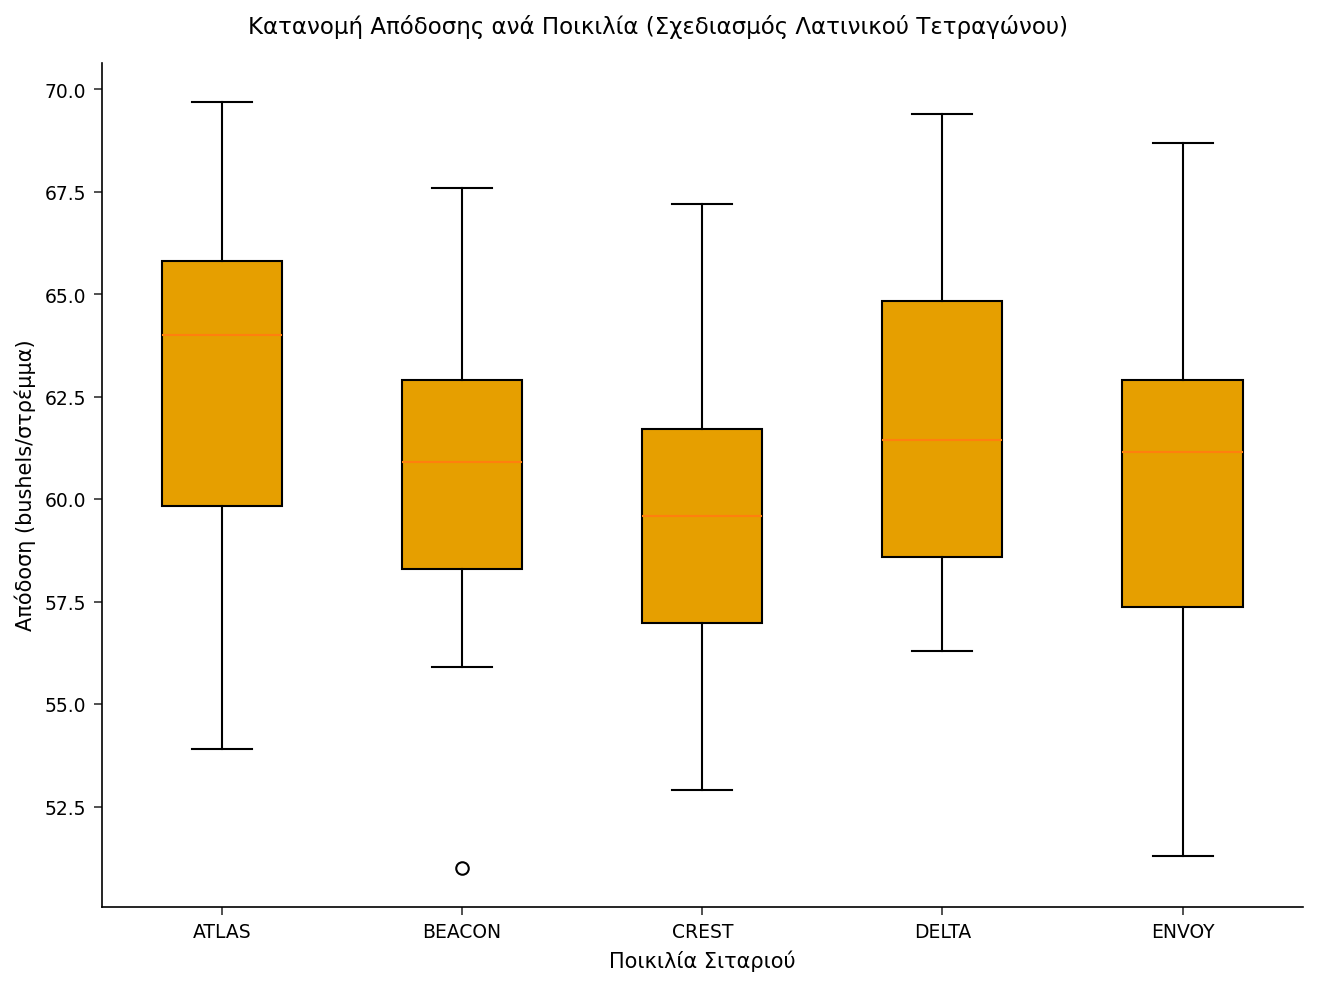

In [3]:
/* --------------------------------------------------------
   Απόδοση ανά ποικιλία με επικάλυψη δομής συνομαδοποίησης
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.field_trial;
    VBOX yield_bpa / category=variety;
    XAXIS ΕΤΙΚΕΤΑ='Ποικιλία Σιταριού';
    YAXIS ΕΤΙΚΕΤΑ='Απόδοση (bushels/στρέμμα)';
    TITLE 'Κατανομή Απόδοσης ανά Ποικιλία (Σχεδιασμός Λατινικού Τετραγώνου)';
ΕΚΤΕΛΕΣΗ;

---

                                The GLM Procedure                                 
               Dependent Variable: yield_bpa Απόδοση (bu/ac)               

Source                         DF  Sum of Squares  Mean Square   F Value    Pr > F
-----------------------  --------  --------------  -----------  --------  --------
Ποικιλία                        4       128.59960     32.14990      2.42    0.0545
Μπλοκ σειράς                    4       251.38060     62.84515      4.73    0.0017
Μπλοκ στήλης                    4        40.96160     10.24040      0.77    0.5473
Error                          87      1156.15930     13.28919                    

Root MSE           3.64543    R-Square            0.2669
Adj R-Sq            0.1658

       Least Squares Means for Ποικιλία       

Level       LSMean  Standard Error  Lower CL  Upper CL
--------  --------  --------------  --------  --------
ATLAS      63.0350          0.8151   61.4148   64.6552
BEACON     60.7200          0.8151   59.099


NOTE: PROC GLM data=work.field_trial

NOTE: OUTPUT dataset written to: ./work/74abd2ed-ae54-46ef-a52a-310c4abae4d1/trial_residuals.avro
NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_variety.spec.json
NOTE: ODS plot written: glm_lsmeans_variety.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


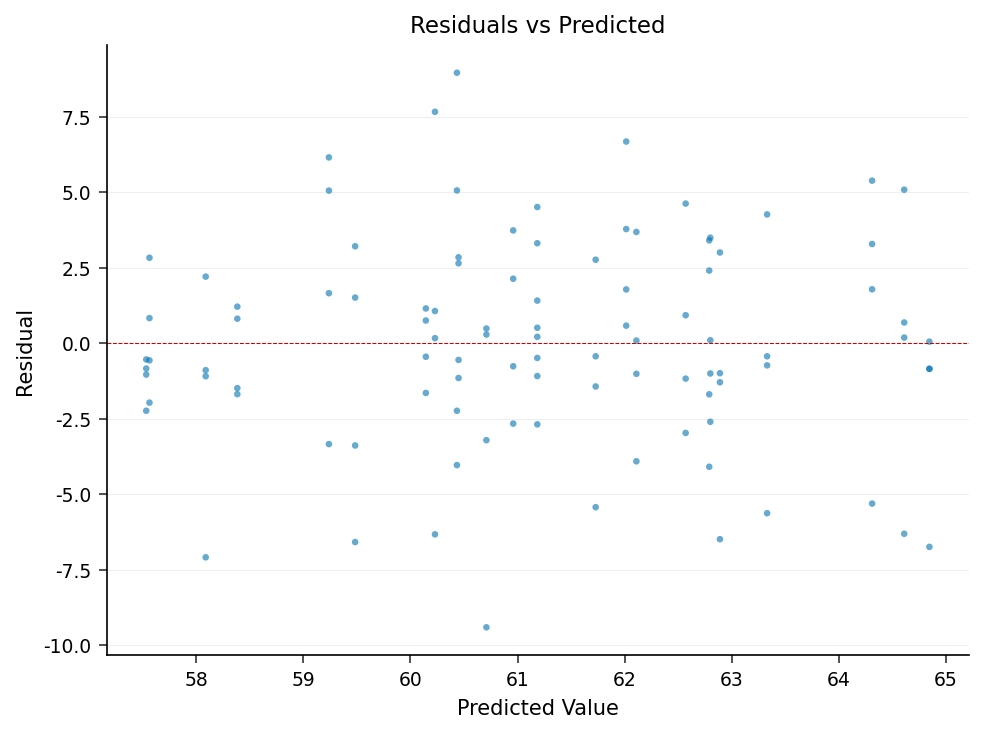

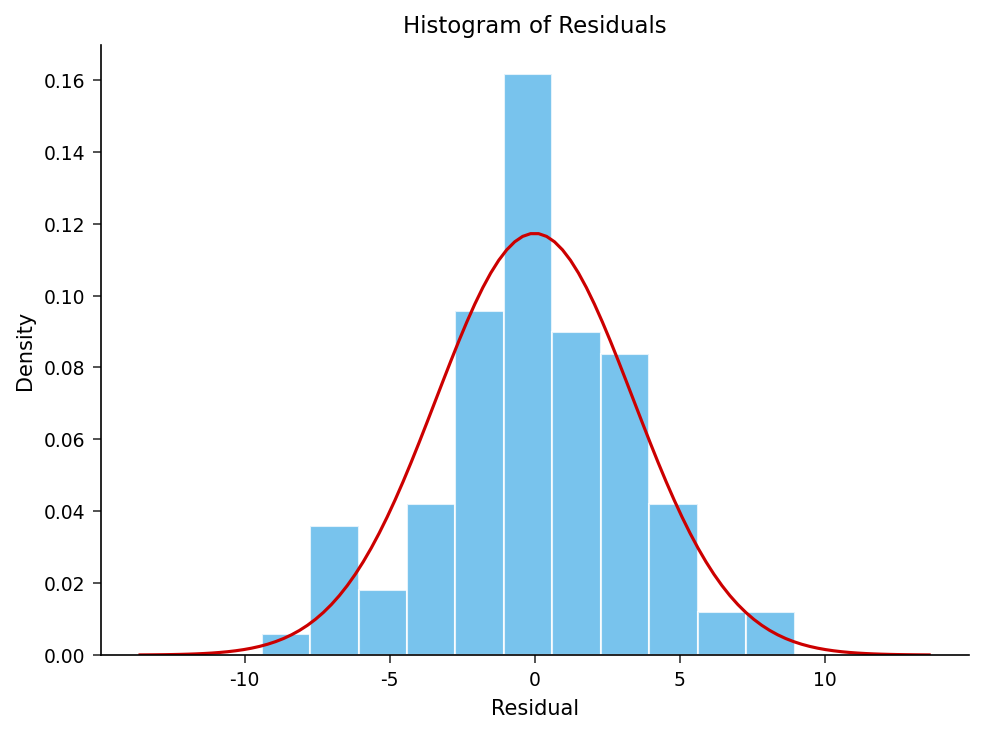

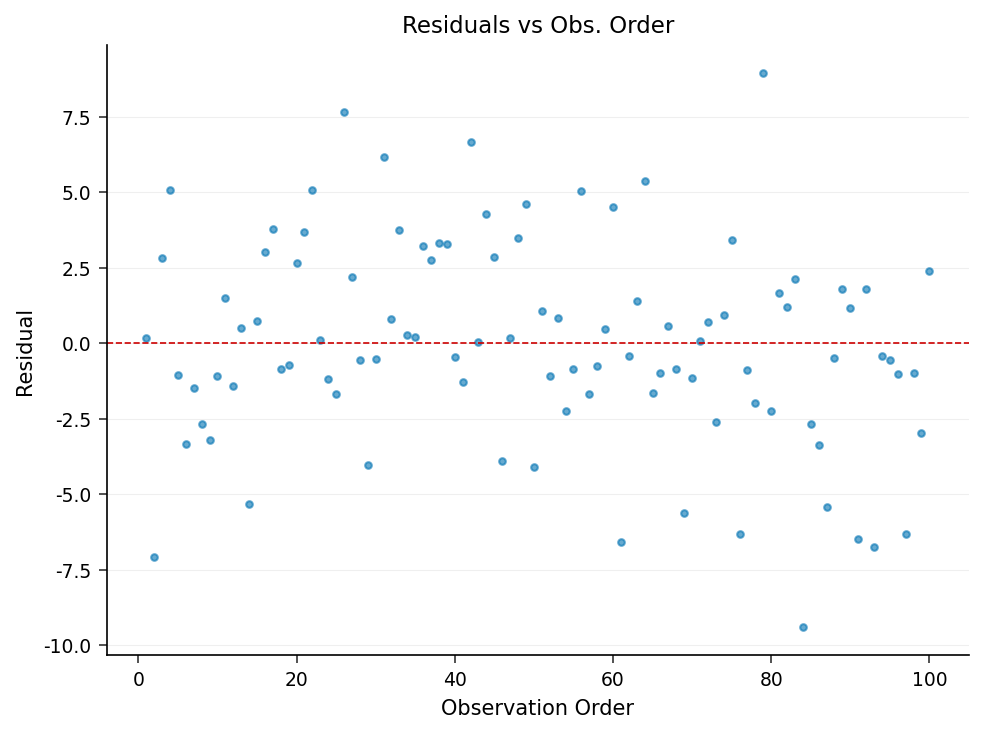

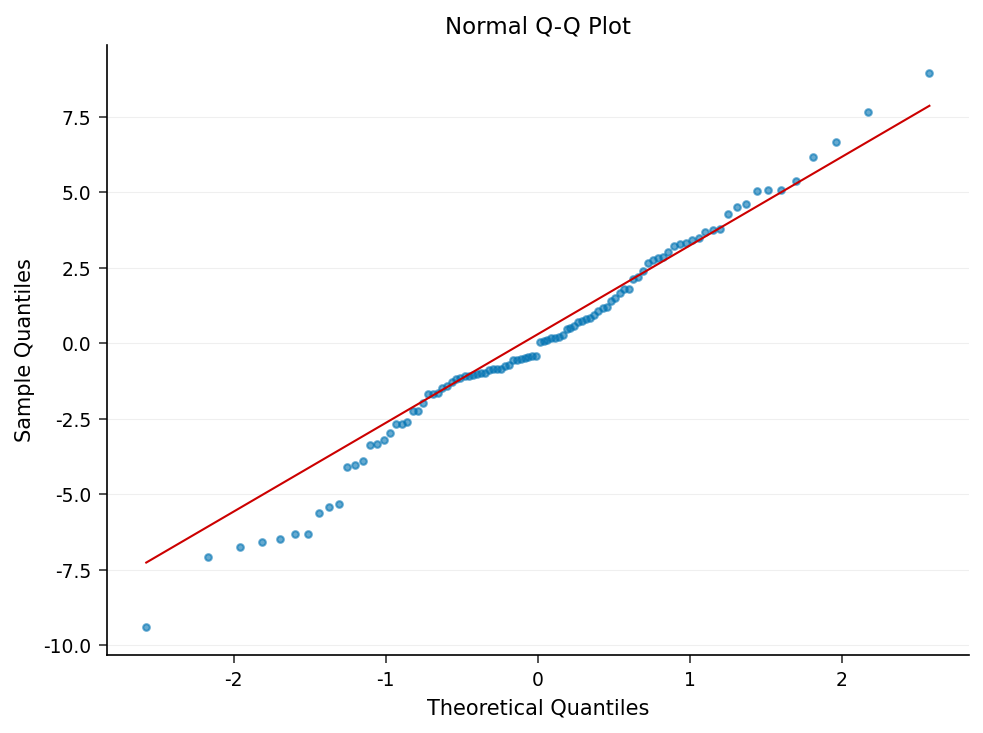

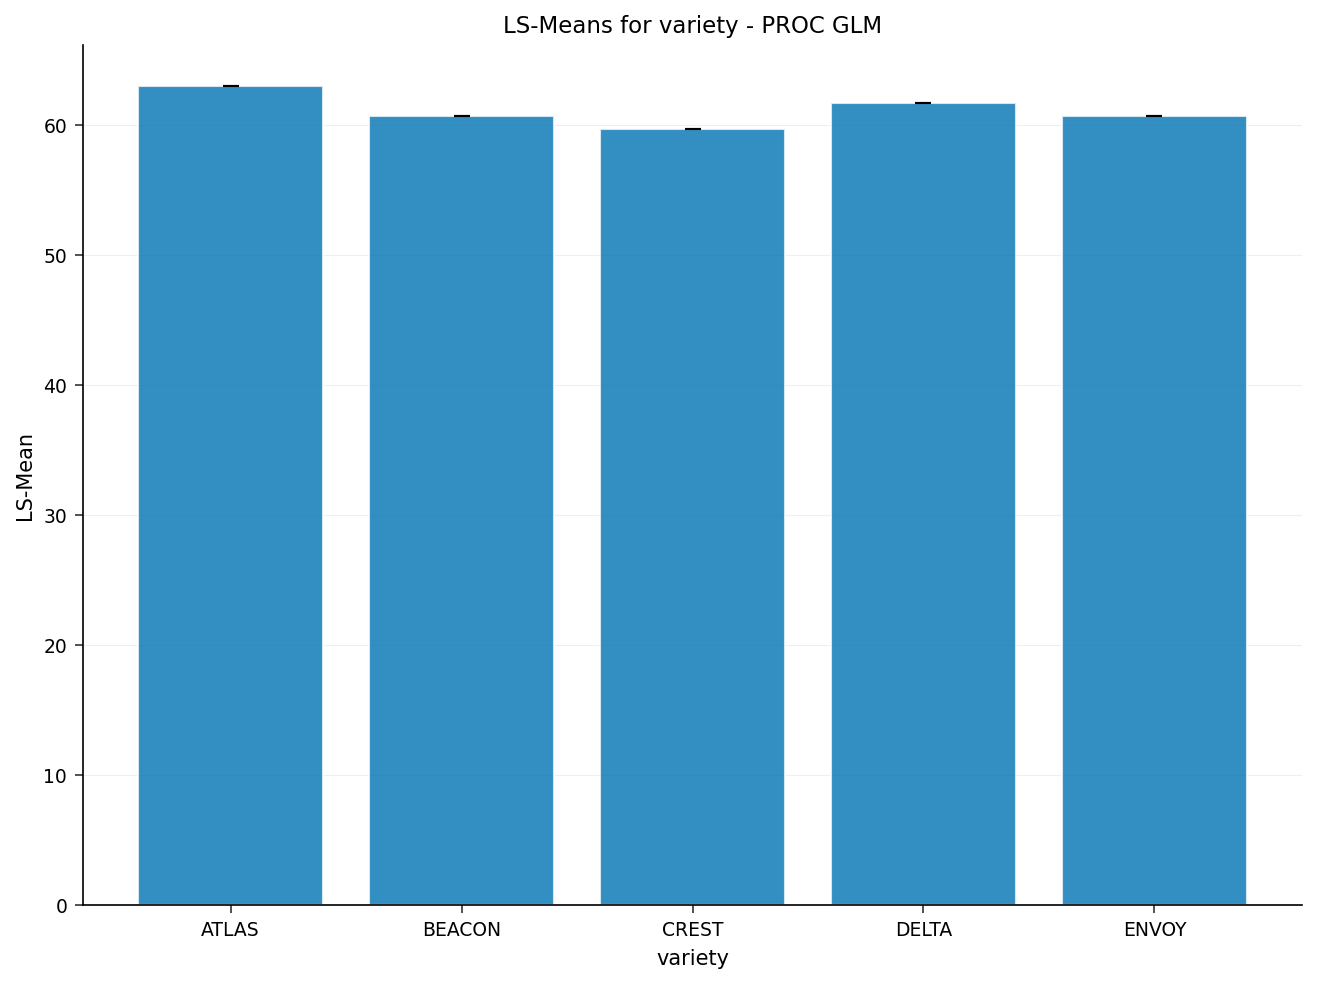

In [4]:
/* --------------------------------------------------------
   ANOVA λατινικού τετραγώνου: ποικιλία προσαρμοσμένη για επιδράσεις
   συνομαδοποίησης σειράς και στήλης
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ GLM ΔΕΔΟΜΕΝΑ=work.field_trial;
    ΚΛΑΣΗ variety row_block col_block;
    ΜΟΝΤΕΛΟ yield_bpa = variety row_block col_block / ss3;
    LSMEANS variety / PDIFF cl ADJUST=TUKEY;
    LSMEANS variety / SLICE=row_block;
    ΕΤΙΚΕΤΑ variety="Ποικιλία" row_block="Μπλοκ σειράς"
          col_block="Μπλοκ στήλης" yield_bpa="Απόδοση (bu/ac)";
    ΕΞΟΔΟΣ out=work.trial_residuals r=residual p=predicted;
ΕΚΤΕΛΕΣΗ;
QUIT;

In [5]:
/* --------------------------------------------------------
   Έλεγχος κανονικότητας στα κατάλοιπα: Shapiro-Wilk και γράφημα QQ
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ UNIVARIATE ΔΕΔΟΜΕΝΑ=work.trial_residuals NORMAL;
    ΜΕΤΑΒΛΗΤΗ residual;
    ΕΤΙΚΕΤΑ residual="Κατάλοιπο";
    HISTOGRAM residual / NORMAL;
    qqplot residual / NORMAL(MU=0 SIGMA=est);
    TITLE 'Έλεγχος Κανονικότητας Καταλοίπων για το Μοντέλο Λατινικού Τετραγώνου';
ΕΚΤΕΛΕΣΗ;

                          Έλεγχος Κανονικότητας Καταλοίπων για το Μοντέλο Λατινικού Τετραγώνου                          

                                                The UNIVARIATE Procedure
                                       Variable:  RESIDUAL  (Κατάλοιπο)

                                                        Moments

N                                100    Sum Weights                      100
Mean                        0.000000    Sum Observations            0.000000
Std Deviation               3.417364    Variance                   11.678377
Skewness                   -0.116922    Kurtosis                    0.250041
Uncorrected SS           1156.159300    Corrected SS             1156.159300
Coeff Variation                    .    Std Error Mean              0.341736

         Basic Statistical Measures          

Location             Variability             
--------  ---------  -------------  ---------
Mean       0.000000  Std Deviation   3.417364
Median    -0.186500


NOTE: PROC UNIVARIATE


---

### Ερμηνεία

**Η συνομαδοποίηση λειτούργησε προς μία κατεύθυνση.** Η θέση σειράς φέρει μια ισχυρή, σημαντική κλίση (F = 4.73, p = 0.0017): η αφαίρεσή της οξύνει κάθε άλλη σύγκριση. Η θέση στήλης όχι (F = 0.77, p = 0.5473) — σε αυτό το πείραμα η κατεύθυνση ανατολής-δύσης είναι ουσιαστικά επίπεδη, οπότε ένας σχεδιασμός συνομαδοποιημένος προς μία μόνο κατεύθυνση θα είχε χάσει λίγα. Η αναφορά και των δύο παραμένει σωστή πρακτική: δεν μπορείς να ξέρεις ότι ένα μπλοκ είναι αδρανές μέχρι να το προσαρμόσεις.

**Οι διαφορές ποικιλίας είναι πραγματικές αλλά μέτριες.** Ο συνολικός έλεγχος F ποικιλίας προσγειώνεται στο p = 0.0545 — μόλις έξω από τη συμβατική σημαντικότητα μόλις αφαιρεθούν και τα δύο μπλοκ. Τα LSMEANS (προσαρμοσμένα για σειρά και στήλη) κατατάσσουν τις ποικιλίες ATLAS 63.04, DELTA 61.76, BEACON 60.72, ENVOY 60.71, CREST 59.69 bu/ac, καθεμία με τυπικό σφάλμα 0.82. Οι κατά ζεύγη διαφορές που ξεπερνούν p < 0.05 αφορούν όλες την ATLAS: ATLAS - CREST (+3.35, p = 0.0047), ATLAS - ENVOY (+2.33, p = 0.0468) και ATLAS - BEACON (+2.32, p = 0.0477). Κανένα άλλο ζεύγος δεν διαχωρίζεται· ειδικότερα, ATLAS - DELTA (+1.28, p = 0.27) δεν είναι διακριτό. Αυτές είναι μη προσαρμοσμένες διαφορές ελαχίστων τετραγώνων μέσων — μια προσαρμογή πολλαπλότητας θα διεύρυνε περαιτέρω τα διαστήματα, οπότε το πλεονέκτημα της ATLAS πρέπει να αντιμετωπίζεται ως ελπιδοφόρο και όχι επιβεβαιωμένο.

**Καμία αλληλεπίδραση ποικιλίας-ανά-σειρά.** Οι έλεγχοι SLICE=row_block αξιολογούν την ποικιλία μέσα σε κάθε θέση σειράς· κανένας δεν είναι σημαντικός (το μικρότερο p είναι 0.0688 στο R3), οπότε η κατάταξη ποικιλιών είναι συνεπής σε όλο τον αγρό αντί να καθοδηγείται από μία ευνοϊκή σειρά.

**Οι υποθέσεις ισχύουν.** Τα κατάλοιπα έχουν μέσο μηδέν με τυπική απόκλιση 3.42 και περνούν και τους τέσσερις ελέγχους κανονικότητας (Shapiro-Wilk p = 0.54, Anderson-Darling p = 0.15), και το γράφημα καταλοίπων έναντι προβλεπόμενων τιμών δεν δείχνει χωνί ή καμπυλότητα. Οι παραμετρικοί έλεγχοι F είναι επομένως έγκυροι.

**Συμπέρασμα.** Η ATLAS είναι η ισχυρότερη υποψήφια, ξεπερνώντας ξεκάθαρα την CREST, αλλά το πείραμα όπως έχει διαστασιολογηθεί (μία περίοδος, τέσσερις επαναλήψεις) αφήνει τη συνολική επίδραση ποικιλίας στο όριο της σημαντικότητας. Θα χρειαζόταν μια δεύτερη περίοδος ή επιπλέον επαναλήψεις για να επιβεβαιωθεί η ATLAS ως η συνιστώμενη ποικιλία για την περιοχή.

---

In [6]:
/* --------------------------------------------------------
   Εξαγωγή σύνοψης απόδοσης ποικιλίας για τους γεωπόνους
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.field_trial NOPRINT;
    ΚΛΑΣΗ variety;
    ΜΕΤΑΒΛΗΤΗ yield_bpa;
    ΕΞΟΔΟΣ out=work.variety_summary
        n=n_plots mean=mean_yield std=std_yield
        MIN=min_yield MAX=max_yield;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.variety_summary
    OUTFILE='latin_square_variety_summary.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC MEANS
NOTE: Output dataset work.variety_summary has 6 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC EXPORT data=work.variety_summary outfile=latin_square_variety_summary.csv

NOTE: Exported 6 rows to latin_square_variety_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την τεχνολογία του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>